#  LAB 6: ATTENTION (IMDB)

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Attention, Concatenate
from tensorflow.keras.models import Model

In [ ]:
# =========================
# LOAD DATA
# =========================
vocab_size = 10000
max_len = 100

(X_train, y_train), _ = imdb.load_data(num_words=vocab_size)
X_train = pad_sequences(X_train, maxlen=max_len)

In [ ]:
# Convert labels to sequence (for Seq2Seq style)
y_seq = np.repeat(y_train.reshape(-1,1), max_len, axis=1)
y_seq = np.expand_dims(y_seq, -1)

In [ ]:
# =========================
# ENCODER
# =========================
encoder_inputs = Input(shape=(max_len,))
encoder_embed = Embedding(vocab_size, 64)(encoder_inputs)

encoder_lstm = LSTM(64, return_sequences=True, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_embed)

In [ ]:
# DECODER
# =========================
decoder_inputs = Input(shape=(max_len,1))
decoder_lstm = LSTM(64, return_sequences=True)
decoder_outputs = decoder_lstm(decoder_inputs, initial_state=[state_h, state_c])

In [ ]:
# =========================
# ATTENTION
# =========================
attention_layer = Attention()
attention_output = attention_layer([decoder_outputs, encoder_outputs])

In [ ]:
# Combine
concat = Concatenate()([decoder_outputs, attention_output])


In [ ]:
# Final output
dense = Dense(1, activation='sigmoid')
final_output = dense(concat)

In [ ]:
# MODEL
# =========================
model = Model([encoder_inputs, decoder_inputs], final_output)
model.compile(optimizer='adam', loss='binary_crossentropy')

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 100, 64)   │    640,000 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 100, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, 100, 64), │     33,024 │ embedding_2[0][0] │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 100, 64)   │     16,896 │ input_layer_4[0]… │
│                     │                   │            │ lstm_3[0][1],     │
│                     │                   │            │ lstm_3[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 100, 64)   │          0 │ lstm_4[0][0],     │
│ (Attention)         │                   │            │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100, 128)  │          0 │ lstm_4[0][0],     │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 100, 1)    │        129 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 690,049 (2.63 MB)

 Trainable params: 690,049 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# TRAIN
# =========================
model.fit([X_train, y_seq], y_seq, epochs=2, batch_size=64)

Epoch 1/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 66s 158ms/step - loss: 0.1075
Epoch 2/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 155ms/step - loss: 0.0100


In [ ]:
# ATTENTION HEATMAP
# =========================

# Take one sample
sample_input = X_train[:1]
sample_target = y_seq[:1]

# Create sub-model to extract attention output
attention_model = Model(
    inputs=model.input,
    outputs=attention_output
)

attention_weights = attention_model.predict([sample_input, sample_target])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step


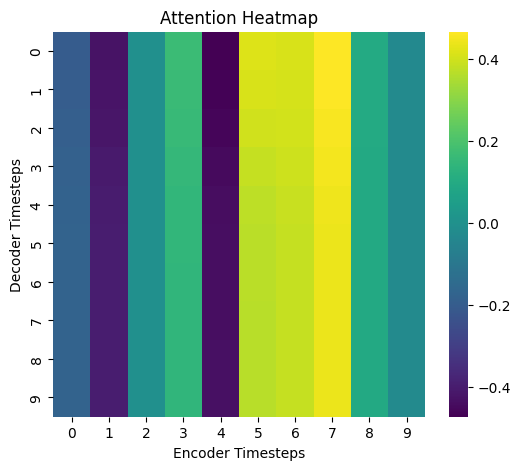

In [ ]:
# Reduce dimensions for visualization
attention_map = attention_weights[0]

plt.figure(figsize=(6,5))
sns.heatmap(attention_map[:10, :10], cmap='viridis')

plt.title("Attention Heatmap")
plt.xlabel("Encoder Timesteps")
plt.ylabel("Decoder Timesteps")

plt.show()